Saving Experiments_5_7_ML_Dataset.csv to Experiments_5_7_ML_Dataset (1).csv
Dataset shape: (500, 9)


,StudyHours,Attendance,AssignmentsCompleted,PreviousScore,SleepHours,InternetUsageHours,PracticeTests,FinalScore,PlacementStatus
0,4.37,86.42,9,51.86,7.18,4.17,0,85.58,1
1,9.56,79.12,4,76.24,7.93,3.51,1,101.26,1
2,7.59,68.93,9,61.66,4.59,7.95,10,101.35,1
3,6.39,91.62,6,75.82,6.05,7.10,8,109.08,1
4,2.40,85.81,2,45.86,8.20,5.18,8,67.22,0


Random Forest Accuracy: 0.92
OOB Score: 0.86
OOB Error: 0.14


,Number of Trees,Test Accuracy,OOB Error
0,10,0.90,0.1700
1,25,0.92,0.1675
2,50,0.92,0.1425
3,100,0.92,0.1400
4,150,0.92,0.1350
5,200,0.92,0.1350


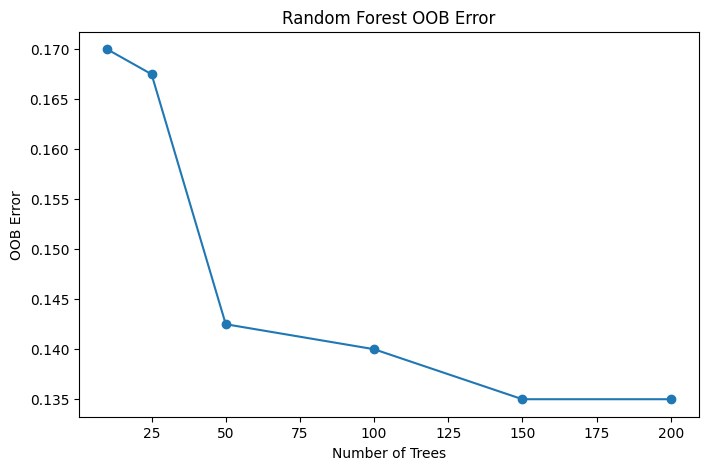

,max_features,Test Accuracy,OOB Error
0,1,0.92,0.1600
1,2,0.92,0.1400
2,3,0.92,0.1375
3,sqrt,0.92,0.1400
4,log2,0.92,0.1400


Feature Importance:


,Feature,Importance
0,StudyHours,0.507357
3,PreviousScore,0.128757
1,Attendance,0.107777
5,InternetUsageHours,0.077792
4,SleepHours,0.076001
6,PracticeTests,0.054909
2,AssignmentsCompleted,0.047407


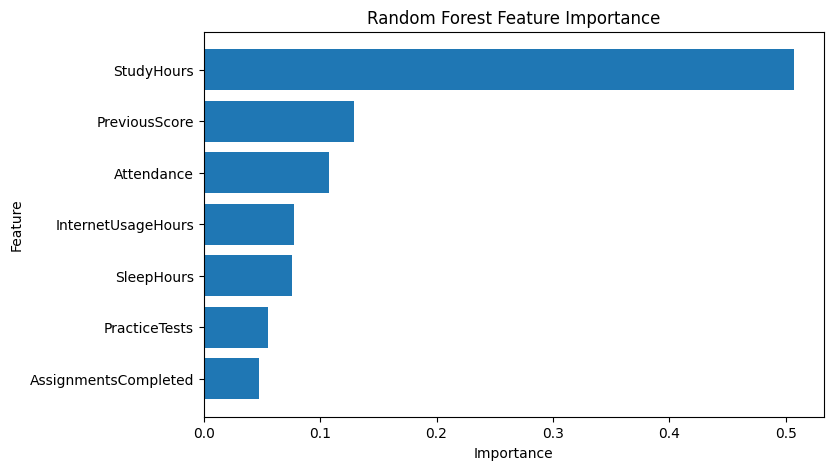

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91        50
           1       0.88      0.98      0.92        50

    accuracy                           0.92       100
   macro avg       0.93      0.92      0.92       100
weighted avg       0.93      0.92      0.92       100



In [1]:
# ============================================
# EXPERIMENT 7
# Random Forest
# OOB Error, Bagging and Feature Subsampling
# ============================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 2: Upload CSV
uploaded = files.upload()

# Step 3: Read dataset
df = pd.read_csv("Experiments_5_7_ML_Dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())

# Step 4: Select features and target
X = df.drop(columns=["FinalScore", "PlacementStatus"])
y = df["PlacementStatus"]

# Step 5: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================
# PART A: RANDOM FOREST
# ============================================

# Step 6: Create Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    bootstrap=True,
    random_state=42
)

# Step 7: Train
rf.fit(X_train, y_train)

# Step 8: Prediction
y_pred = rf.predict(X_test)

# Step 9: Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy, 4))

# Step 10: OOB Score
print("OOB Score:", round(rf.oob_score_, 4))

# OOB Error
oob_error = 1 - rf.oob_score_

print("OOB Error:", round(oob_error, 4))

# ============================================
# PART B: NUMBER OF TREES
# ============================================

trees = [10, 25, 50, 100, 150, 200]

test_accuracies = []
oob_errors = []

for n in trees:

    model = RandomForestClassifier(
        n_estimators=n,
        max_features="sqrt",
        oob_score=True,
        bootstrap=True,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    test_acc = accuracy_score(
        y_test,
        prediction
    )

    oob_error_value = 1 - model.oob_score_

    test_accuracies.append(test_acc)
    oob_errors.append(oob_error_value)

# Step 11: Display results
results = pd.DataFrame({
    "Number of Trees": trees,
    "Test Accuracy": test_accuracies,
    "OOB Error": oob_errors
})

display(results)

# ============================================
# PART C: PLOT OOB ERROR
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    trees,
    oob_errors,
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error")

plt.show()

# ============================================
# PART D: FEATURE SUBSAMPLING
# ============================================

feature_options = [
    1,
    2,
    3,
    "sqrt",
    "log2"
]

feature_results = []

for option in feature_options:

    model = RandomForestClassifier(
        n_estimators=100,
        max_features=option,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    oob_error = 1 - model.oob_score_

    feature_results.append([
        str(option),
        accuracy,
        oob_error
    ])

# Step 12: Display feature subsampling results
feature_df = pd.DataFrame(
    feature_results,
    columns=[
        "max_features",
        "Test Accuracy",
        "OOB Error"
    ]
)

display(feature_df)

# ============================================
# PART E: FEATURE IMPORTANCE
# ============================================

final_model = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

final_model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(importance)

# Step 13: Plot feature importance
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# ============================================
# PART F: CLASSIFICATION REPORT
# ============================================

final_prediction = final_model.predict(X_test)

print("Classification Report:")
print(
    classification_report(
        y_test,
        final_prediction
    )
)